In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0,random_state=42)

In [ ]:
pd.DataFrame(X)

,0,1
0,0.601034,1.535353
1,0.755945,-1.172352
2,1.354479,-0.948528
3,3.103090,0.233485
4,0.753178,0.787514
...,...,...
995,1.713939,0.451639
996,1.509473,-0.794996
997,2.844315,0.211294
998,-0.025876,1.619258


<Axes: xlabel='0', ylabel='1'>

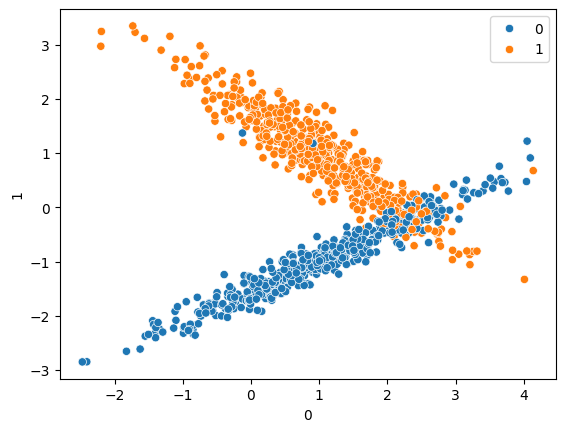

In [ ]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=10)

In [ ]:
from sklearn.svm import SVC
svc=SVC()

In [ ]:
svc.fit(X_train,y_train)

SVC()

In [ ]:
y_pred=svc.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))


[[89 14]
 [ 0 97]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.93       103
           1       0.87      1.00      0.93        97

    accuracy                           0.93       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.93      0.93       200



In [ ]:
param_grid={'C':[0.1,1,10,100,1000],
           'gamma':[1,0.1,0.01,0.001,0.0001],
           'kernel':['linear', 'poly', 'rbf', 'sigmoid']}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,verbose=3,cv=5)

In [ ]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.931 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.925 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.912 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.881 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.925 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.944 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.925 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.925 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.919 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.938 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.950 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rb

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             verbose=3)

In [ ]:
grid.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
grid.best_score_

np.float64(0.9475)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[89 14]
 [ 0 97]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.93       103
           1       0.87      1.00      0.93        97

    accuracy                           0.93       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.93      0.93       200



# Kernel Implementation Manually for non linearly seperable/mixed dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
x=np.hstack([x,-x])
y=np.hstack([y,-y])


In [ ]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
x1=np.hstack([x1,-x1])
y1=np.hstack([y1,-y1])


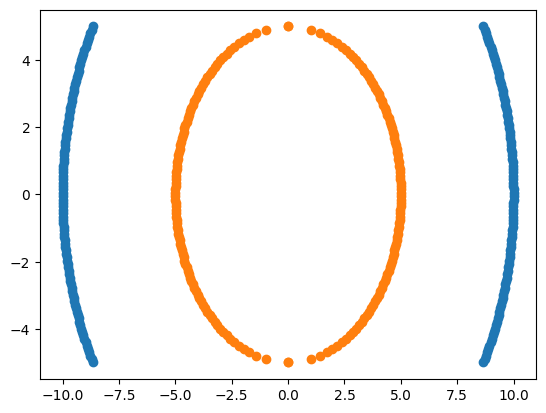

In [ ]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [ ]:
y

array([ 8.66025404,  8.71779204,  8.77378994,  8.82827705,  8.88128118,
        8.93282873,  8.98294476,  9.03165312,  9.07897646,  9.12493632,
        9.16955321,  9.21284664,  9.25483518,  9.29553652,  9.3349675 ,
        9.37314414,  9.41008171,  9.44579475,  9.4802971 ,  9.51360192,
        9.54572176,  9.57666854,  9.60645359,  9.63508769,  9.66258107,
        9.68894344,  9.714184  ,  9.73831149,  9.76133416,  9.7832598 ,
        9.80409577,  9.82384901,  9.84252604,  9.86013297,  9.87667553,
        9.89215905,  9.90658851,  9.91996849,  9.93230325,  9.94359667,
        9.9538523 ,  9.96307334,  9.97126266,  9.9784228 ,  9.98455598,
        9.98966408,  9.99374868,  9.99681104,  9.99885209,  9.99987246,
        9.99987246,  9.99885209,  9.99681104,  9.99374868,  9.98966408,
        9.98455598,  9.9784228 ,  9.97126266,  9.96307334,  9.9538523 ,
        9.94359667,  9.93230325,  9.91996849,  9.90658851,  9.89215905,
        9.87667553,  9.86013297,  9.84252604,  9.82384901,  9.80

In [ ]:
np.vstack([y,x]).T

array([[ 8.66025404, -5.        ],
       [ 8.71779204, -4.8989899 ],
       [ 8.77378994, -4.7979798 ],
       [ 8.82827705, -4.6969697 ],
       [ 8.88128118, -4.5959596 ],
       [ 8.93282873, -4.49494949],
       [ 8.98294476, -4.39393939],
       [ 9.03165312, -4.29292929],
       [ 9.07897646, -4.19191919],
       [ 9.12493632, -4.09090909],
       [ 9.16955321, -3.98989899],
       [ 9.21284664, -3.88888889],
       [ 9.25483518, -3.78787879],
       [ 9.29553652, -3.68686869],
       [ 9.3349675 , -3.58585859],
       [ 9.37314414, -3.48484848],
       [ 9.41008171, -3.38383838],
       [ 9.44579475, -3.28282828],
       [ 9.4802971 , -3.18181818],
       [ 9.51360192, -3.08080808],
       [ 9.54572176, -2.97979798],
       [ 9.57666854, -2.87878788],
       [ 9.60645359, -2.77777778],
       [ 9.63508769, -2.67676768],
       [ 9.66258107, -2.57575758],
       [ 9.68894344, -2.47474747],
       [ 9.714184  , -2.37373737],
       [ 9.73831149, -2.27272727],
       [ 9.76133416,

In [ ]:
import pandas as pd
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df=pd.concat([df1, df2])
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [ ]:
df.tail()

,X1,X2,Y
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1
199,-0.000000,-5.00000,1


In [ ]:
X=df.iloc[:,:2]
y=df.Y

In [ ]:
pd.DataFrame(X)

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596
...,...,...
195,-1.969049,-4.59596
196,-1.714198,-4.69697
197,-1.406908,-4.79798
198,-0.999949,-4.89899


# K(x, y) = (xTy + c)d

In [ ]:
df['X1_squared']=df['X1']**2
df['X2_squared']=df['X2']**2
df['X1*X2']=df['X1']*df['X2']

In [ ]:
df.head()

,X1,X2,Y,X1_squared,X2_squared,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [ ]:
import plotly.express as px
px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')

In [ ]:
px.scatter_3d(df,x='X1_squared',y='X2_squared',z='X1*X2',color='Y')

In [ ]:
X=df[['X1','X2','X1_squared','X2_squared','X1*X2']]
y=df.Y

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=10)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='linear')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.3875

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.6125

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='sigmoid')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.5375

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='rbf')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0